[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03b_turbo.ipynb)

# 03b — Bayesian Optimization with TuRBO

## 1. Overview

This notebook runs **TuRBO**, the proposed method for multi-band antenna tilt coordination, and reads it against the
baselines of notebook 03a.

**Question.** Does a model-guided search find a better tilt configuration than random search for the same number of
ray-traced evaluations, and than the rule-based sweep at any budget?

**Goals.**

- Run TuRBO on the same simulator, scenario, objective and evaluation budget as random search.
- Show how the trust region spends that budget.
- Measure what the best configuration changes on every KPI, and where on the map, beside both baselines.

The problem formulation is described in notebook 01, the setup tables and the objective $J$ in notebook 03a
(sections 3 and 7); they are not repeated here.

**Outputs.** One run directory per seed under `outputs/optim/turbo/`, tables under `reports/tables/03b_turbo/`,
figures under `reports/figures/03b_turbo/`. **Requirements.** A CUDA GPU, and notebook 03a run first. The shell
equivalent of the run is `task bo`.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt"), ("botorch", "botorch")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation import compare, maps, plots
from src.evaluation import runs as run_store
from src.evaluation.export import readable, save_table
from src.kpi.capacity import CapacitySpec, max_rsrp
from src.kpi.overlap import overlap_neighbors
from src.optim.methods.turbo.search import TURBO, TrustRegion
from src.optim.objective import MAXIMISED
from src.optim.run import run
from src.optim.space import TiltSpace
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03b_turbo"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03b_turbo"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

# Search seeds, matched to 03a: optim.seed from the config; BAND_TILT_SEEDS (space-separated) overrides it.
SEEDS = [int(seed) for seed in os.environ.get("BAND_TILT_SEEDS", str(cfg.optim.seed)).split()]
METHODS = ("turbo", "random", "rule")

## 2. Method

TuRBO (Eriksson et al., 2019, `optim/method=turbo`) keeps one trust region, a box around the best point found so far,
and searches only inside it:

1. Evaluate the current configuration, then an initial Sobol design of `n_init` points. It is the same design random
   search starts with, so the two differ only in where they look afterwards.
2. Fit a Gaussian process to the objective $J$ of every evaluation since the last restart, in the unit cube the tilt
   box is rescaled to.
3. Centre the trust region on the best point, with side lengths stretched along the dimensions the GP finds smooth.
4. Draw candidates inside the region, perturbing a random subset of dimensions, and pick a batch of `batch_size` by
   Thompson sampling from the GP posterior.
5. Ray-trace the batch. After `success_tolerance` improving rounds the region doubles; after the failure tolerance of
   non-improving rounds it halves.
6. When the region shrinks below `length_min`, restart: a fresh Sobol design and a GP that forgets the collapsed
   region. Restarts spend the same budget.

Every candidate is ray-traced and scored exactly as in 03a; the GP only chooses where to look, and no reported number
comes from it.

## 3. Configuration

In [3]:
space = TiltSpace.from_config(cfg)
baseline = run_store.baseline_map(cfg)
cells = pd.read_parquet(cfg.data.output.cell_file).drop_duplicates("cell")
ue = pd.read_parquet(cfg.data.output.ue_file)

turbo_cfg = load_config(overrides=["optim/method=turbo", *CONFIG_OVERRIDES])
budget = turbo_cfg.optim.method.budget
region = TrustRegion.from_config(turbo_cfg, space.n_dim, int(budget.batch_size))
settings = pd.DataFrame(
    {
        "Parameter": [
            "Optimized variables",
            "Evaluations (excluding the incumbent)",
            "Budget split",
            "Batch size",
            "Trust region length: initial, minimum, maximum",
            "Success tolerance (rounds)",
            "Failure tolerance (rounds)",
            "Search seeds",
            "Solutions published",
        ],
        "Value": [
            space.n_dim,
            int(budget.n_init) + int(budget.n_iter),
            f"n_init={budget.n_init}, n_iter={budget.n_iter}",
            region.batch_size,
            f"{region.length_init:g}, {region.length_min:g}, {region.length_max:g}",
            region.success_tolerance,
            region.failure_tolerance,
            ", ".join(map(str, SEEDS)),
            int(turbo_cfg.optim.n_solutions),
        ],
    }
)
save_table(settings, "turbo_configuration")
settings

,Parameter,Value
0,Optimized variables,36
1,Evaluations (excluding the incumbent),144
2,Budget split,"n_init=16, n_iter=128"
3,Batch size,3
4,"Trust region length: initial, minimum, maximum","0.8, 0.0078125, 1.6"
5,Success tolerance (rounds),3
6,Failure tolerance (rounds),12
7,Search seeds,42
8,Solutions published,4


## 4. Runs

A TuRBO run already on disk for the same seed and the current scenario is reused; delete its directory under
`outputs/optim/turbo/` to repeat it. Runs from an earlier scenario are ignored. The baseline runs are read from disk,
not repeated, and every run is checked comparable with the current radio map.

In [4]:
scenario = str(baseline["scenario_id"])


def on_disk():
    # The newest finished run of each method and seed on the current scenario.
    current = [r for r in run_store.discover(cfg.optim.output.dir) if r.scenario_id == scenario]
    return run_store.latest_per_method_and_seed(current)


done = {(r.method, r.seed) for r in on_disk()}
for seed in SEEDS:
    if ("turbo", seed) not in done:
        run(load_config(overrides=["optim/method=turbo", f"optim.seed={seed}", *CONFIG_OVERRIDES]))

runs = [
    r
    for r in on_disk()
    if r.method == "rule" or (r.method in ("turbo", "random") and r.seed in SEEDS)
]
missing = [m for m in METHODS if not any(r.method == m for r in runs)]
if missing:
    raise run_store.RunError(
        f"No {', '.join(missing)} run on scenario {scenario}; run notebook 03a first."
    )
checks = run_store.verify(runs, baseline)
run_store.require(checks)
print(f"{len(runs)} runs; {int(checks['holds'].sum())} of {len(checks)} comparability checks hold")
best = compare.best_run_per_method(runs)
turbo = best["turbo"]

jitc_llvm_init(): LLVM API initialization failed ..



turbo: 4 solutions published

 solution  recommended  hole_rate  overlap_rate  overlap_neighbor_mean  weak_rate  rsrp_p05_dbm  rsrp_p50_dbm  sinr_p05_db  sinr_p50_db  served_rate  prb_utilisation_max  load_imbalance  objective
        0        False     0.1125        0.3164                 0.9625     0.3069     -108.5644      -84.1068      -5.8729       8.4932       0.5265               0.7999          0.9098     4.5640
        1         True     0.1078        0.3088                 1.0343     0.2650     -107.3805      -81.5408      -5.0017      11.1267       0.5947               0.7993          1.0042     5.1648
        2        False     0.1070        0.3076                 1.0433     0.2621     -107.3983      -81.3374      -4.9993      10.6490       0.5941               0.8000          0.9997     5.1630
        3        False     0.1078        0.3084                 1.0099     0.2659     -107.4083      -81.6106      -5.0145      10.6745       0.5943               0.7996          1.

3 runs; 23 of 23 comparability checks hold


## 5. Search Progress

Best objective found so far per evaluation, from the search history, for TuRBO and both baselines. With several seeds
the line is the mean and the band spans the best and worst seed.

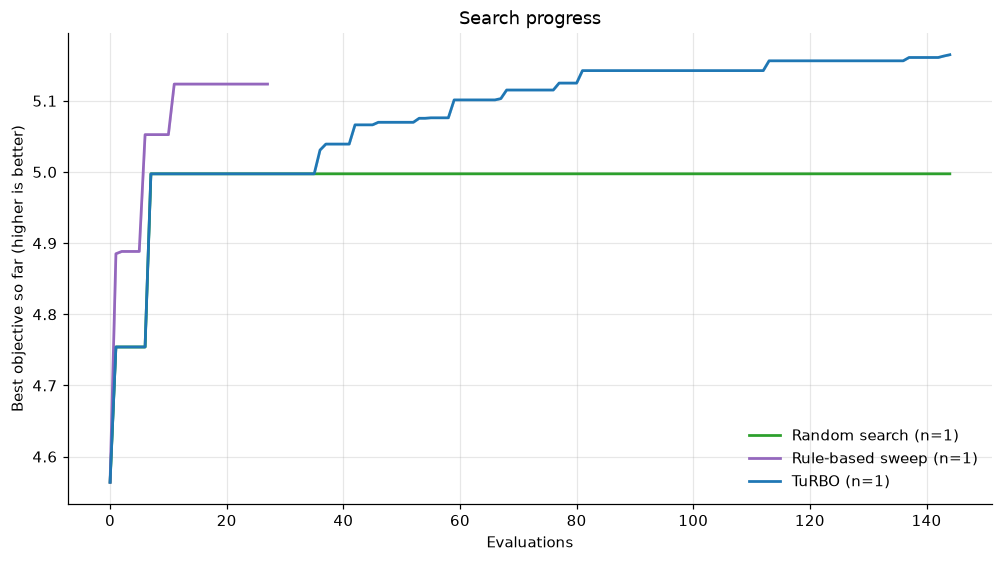

In [5]:
figure = plots.convergence_plot(compare.convergence(runs))
save_fig(figure, "search_progress")
plt.show()

### Where TuRBO spent its budget

Every evaluation of TuRBO's best run, marked by what proposed it. A Sobol block after the initial design is a restart.

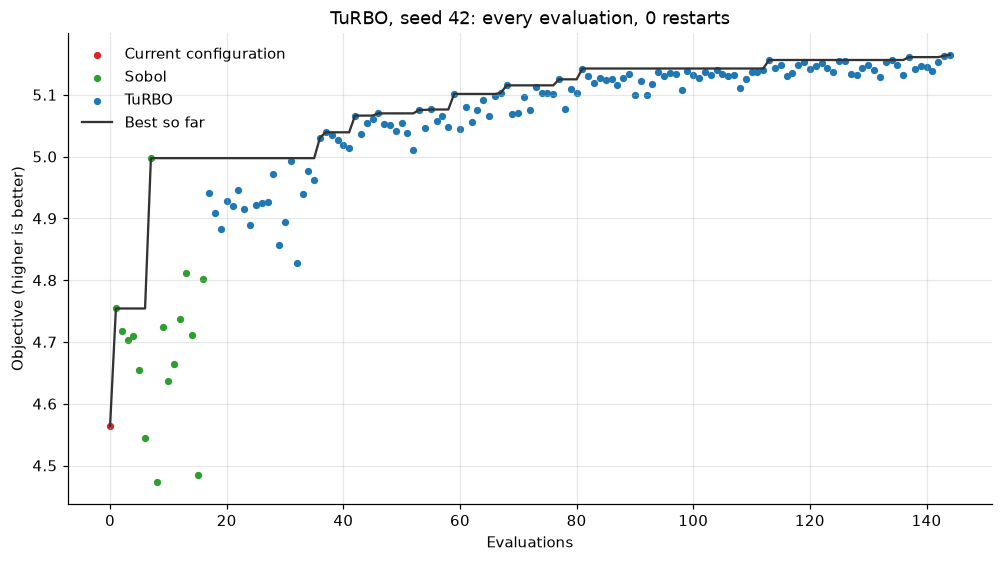

,Evaluations,Mean objective,Best objective
Proposed by,,,
Current configuration,1,4.5640,4.5640
Sobol,16,4.6952,4.9974
TuRBO,128,5.0806,5.1648


In [6]:
history = turbo.history
proposer = history["generation_node"].replace({"attached": "Current configuration"})
colours = {
    "Current configuration": plots.COLOURS["incumbent"],
    "Sobol": plots.COLOURS["random"],
    TURBO: plots.COLOURS["turbo"],
}
from_model = (history["generation_node"] == TURBO).to_numpy()
# A restart is a Sobol row directly after a trust-region proposal.
restarts = int((~from_model[1:] & from_model[:-1]).sum())

figure, axis = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
for name, group in history.groupby(proposer, sort=False):
    axis.scatter(group["iteration"], group["objective"], s=14, color=colours[name], label=name)
axis.plot(history["iteration"], history["objective"].cummax(), color="0.2", lw=1.5, label="Best so far")
axis.set_xlabel("Evaluations")
axis.set_ylabel("Objective (higher is better)")
axis.set_title(f"TuRBO, seed {turbo.seed}: every evaluation, {restarts} restarts")
axis.legend()
save_fig(figure, "turbo_evaluations")
plt.show()

by_proposer = history.groupby(proposer, sort=False)["objective"].agg(["size", "mean", "max"])
by_proposer = by_proposer.rename(
    columns={"size": "Evaluations", "mean": "Mean objective", "max": "Best objective"}
).rename_axis("Proposed by")
save_table(by_proposer.reset_index(), "turbo_evaluations_by_proposer")
by_proposer

**Observations.** Random search stops improving at evaluation 7 of 145, inside the Sobol design it shares with
TuRBO, and the rule-based sweep gets nearly all of its gain from its first pass. TuRBO starts from that same design and
keeps improving through the budget in small steps. Because the first 16 points are shared, TuRBO *ties* random search's
best at evaluation 7 rather than beating it there; it passes the rule sweep's best at evaluation 81. The trust-region
proposals score higher on average than the design points (5.617 against 5.216 over 128 and 16 evaluations), so the model
is steering rather than scattering. Only 16 Sobol points appear in the whole history, so the region never collapsed and
no restart was spent - and the best configuration is evaluation 115 of 144, so the search was still improving late.

## 6. Best Tilt Configuration

The deliverable of TuRBO's best run: current and proposed tilt per cell-band. Negative change is uptilt.

TuRBO: run 2026-09-19_09-06-56, seed 42, best evaluation 144


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,6.3886,9.9928,-6.3886
1,2600 MHz,12,12,8.7972,11.9188,-8.7972
2,700 MHz,12,12,6.1882,7.9729,-3.4254


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,0.0812,-11.9188,0.0,15.0
1,n0c0,1800 MHz,10.0,1.4789,-8.5211,0.0,15.0
2,n0c0,700 MHz,8.0,0.0271,-7.9729,0.0,15.0
3,n0c1,2600 MHz,12.0,3.6561,-8.3439,0.0,15.0
4,n0c1,1800 MHz,10.0,3.2663,-6.7337,0.0,15.0
5,n0c1,700 MHz,8.0,1.0160,-6.9840,0.0,15.0
6,n0c2,2600 MHz,12.0,0.2440,-11.7560,0.0,15.0
7,n0c2,1800 MHz,10.0,4.2246,-5.7754,0.0,15.0
8,n0c2,700 MHz,8.0,13.4910,5.4910,0.0,15.0
9,n1c0,2600 MHz,12.0,8.6684,-3.3316,0.0,15.0


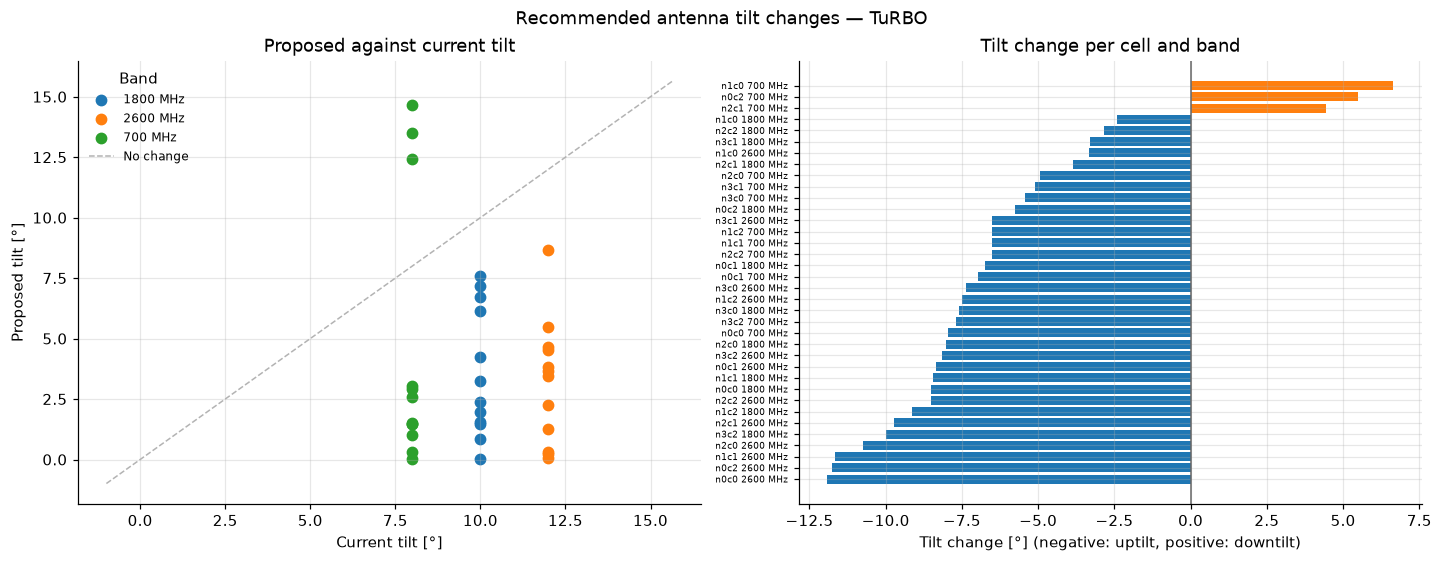

In [7]:
tilt = readable(turbo.best_tilt)
save_table(tilt, "best_tilt_turbo")
summary = readable(compare.tilt_movement(turbo))
save_table(summary, "tilt_movement_turbo")
print(
    f"{label('turbo')}: run {turbo.run_id}, seed {turbo.seed}, best evaluation {turbo.best_index}"
)
display(summary)
display(tilt)
figure = plots.tilt_movement_plot(turbo.best_tilt, "turbo")
save_fig(figure, "tilt_movement_turbo")
plt.show()

**Observations.** Unlike the rule sweep, which moves a whole band at once, TuRBO chooses per cell-band: 34 of
the 36 are uptilted and 2 downtilted. Proposed tilts span 0.08° to 8.64°, so the search sits against the *bottom* of
the 0-15° box and never approaches the top. On average it uptilts 2600 MHz by 9.8°, 1800 MHz by 8.0° and 700 MHz by
4.9°, with a largest single change of 11.9°. The one-sidedness is the softplus utility at work: coverage keeps
paying above $T_\text{cov}$, so spreading each footprint further is rewarded where it used to saturate. With a single seed it is not established which of these per-cell differences matter and which are where the trust
region happened to be when the budget ended.

## 7. Final Results

### KPI comparison

TuRBO's best configuration against the current one, on every UE. Relative improvement is signed so that positive is
better whichever direction the KPI runs, as in 03a:

$$
\text{Improvement} = s \cdot \frac{KPI_\text{optimized} - KPI_\text{initial}}{|KPI_\text{initial}|} \times 100\%,
\qquad s = \begin{cases} +1 & \text{maximised} \\ -1 & \text{minimised} \end{cases}
$$

Then every method side by side: what its best run found on every UE, and what it cost.

In [8]:
table = compare.delta_table(turbo.incumbent_kpi, turbo.best_kpi)
sign = np.where(table["kpi"].isin(MAXIMISED), 1.0, -1.0)
table["improvement_pct"] = 100.0 * sign * table["delta"] / table["before"].abs()
table = readable(table).rename(
    columns={
        "direction": "Direction",
        "before": "Initial",
        "after": label("turbo"),
        "delta": "Change",
        "verdict": "Verdict",
        "improvement_pct": "Improvement [%]",
    }
)
save_table(table, "kpi_comparison_turbo")
display(table)

results = readable(compare.method_table(runs).drop(columns=["run"]))
save_table(results, "method_results")
results

,KPI,Direction,Initial,TuRBO,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.1125,0.1078,-0.0047,better,4.1784
1,Co-band overlap rate,minimise,0.3164,0.3088,-0.0076,better,2.3894
2,Overlap neighbours per covered tile,minimise,0.9625,1.0343,0.0717,worse,-7.4512
3,Weak coverage rate,minimise,0.3069,0.2650,-0.0420,better,13.6731
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644,-107.3805,1.1839,better,1.0905
5,"Median RSRP, p50 [dBm]",maximise,-84.1068,-81.5408,2.5660,better,3.0509
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729,-5.0017,0.8712,better,14.8339
7,"Median SINR, p50 [dB]",maximise,8.4932,11.1267,2.6334,better,31.0062
8,Served UE rate,maximise,0.5265,0.5947,0.0682,better,12.9542
9,Peak PRB utilisation,minimise,0.7999,0.7993,-0.0006,better,0.0773


,Method,Seed,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Peak PRB utilisation,Cell load imbalance (CoV),Objective J,KPIs improved,KPIs worsened
0,Random search,42,145,7,7.3827,10.7881,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092,4.9974,9,3
1,Rule-based sweep,42,28,11,1.0856,1.9181,0.1043,0.3212,1.1888,0.2539,-106.9845,-80.8414,-4.9962,9.8217,0.5981,0.7999,0.9844,5.1236,9,3
2,TuRBO,42,145,144,9.4247,18.0716,0.1078,0.3088,1.0343,0.2650,-107.3805,-81.5408,-5.0017,11.1267,0.5947,0.7993,1.0042,5.1648,10,2


**Observations.** TuRBO reaches the highest objective of the three methods: 5.6972, against 5.6756 for the
sweep and 5.5118 for random search, from an incumbent of 5.0568. $J$ is a per-band sum (ADR 0007) with a softplus
coverage utility (ADR 0008), so it is non-negative and unbounded rather than confined to $[0, 3]$, and these values
are not comparable with any figure recorded before that change. It improves 10 of the 12 reported measures, and it
is the only method to cut the co-band overlap rate at all - 0.3164 to 0.3122, 1.3 % relative - where both baselines
raise it. Its largest relative move is the median SINR over covered tiles, +19.6 % (8.5 to 10.2 dB), followed by the
cell-edge SINR at +17.1 %. The two it worsens are overlap neighbours per covered tile (+16.3 %, worse than random
search's +7.0 % and better than the sweep's +25.3 %) and cell load imbalance (+11.0 %, which the objective does not
read). TuRBO spent slightly more ray-tracing time than random search for the same number of evaluations, and the
longest wall clock of all three (14.2 minutes), because each round also fits a GP.

Its margin over the rule sweep is now narrower than the softplus change makes the gains look: +12.7 % against
+12.2 %, on 145 evaluations against 28. Under the logistic utility the ordering was the same but the gains were a
third the size (+4.2 % and +3.7 %). The whole of TuRBO's margin is again co-band overlap, the one thing a per-band
sweep structurally cannot fix - but note that every method now raises overlap neighbours per covered tile, and by
more than any did before, which is the trade an unbounded coverage utility buys.

## 8. Coverage Map Comparison

Best-server RSRP before and after TuRBO, and the tiles that crossed the coverage-hole threshold; then the RSRP change
of each method's best configuration on one scale. Crimson triangles are the masts.

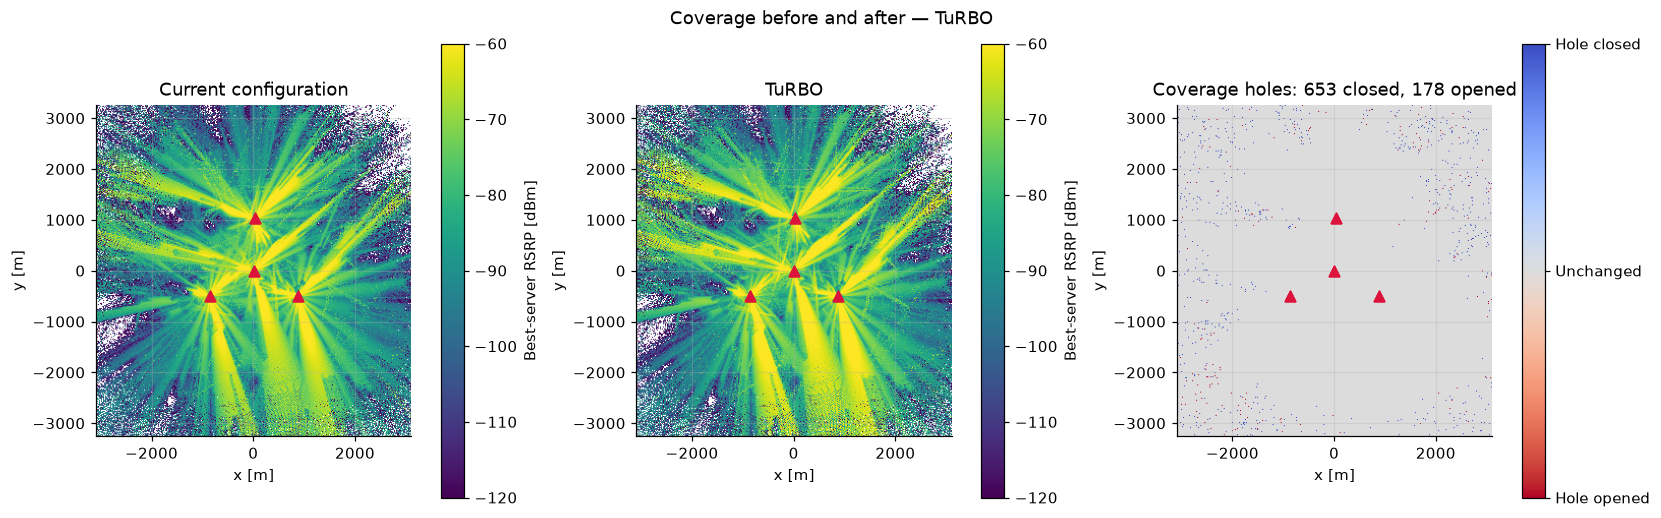

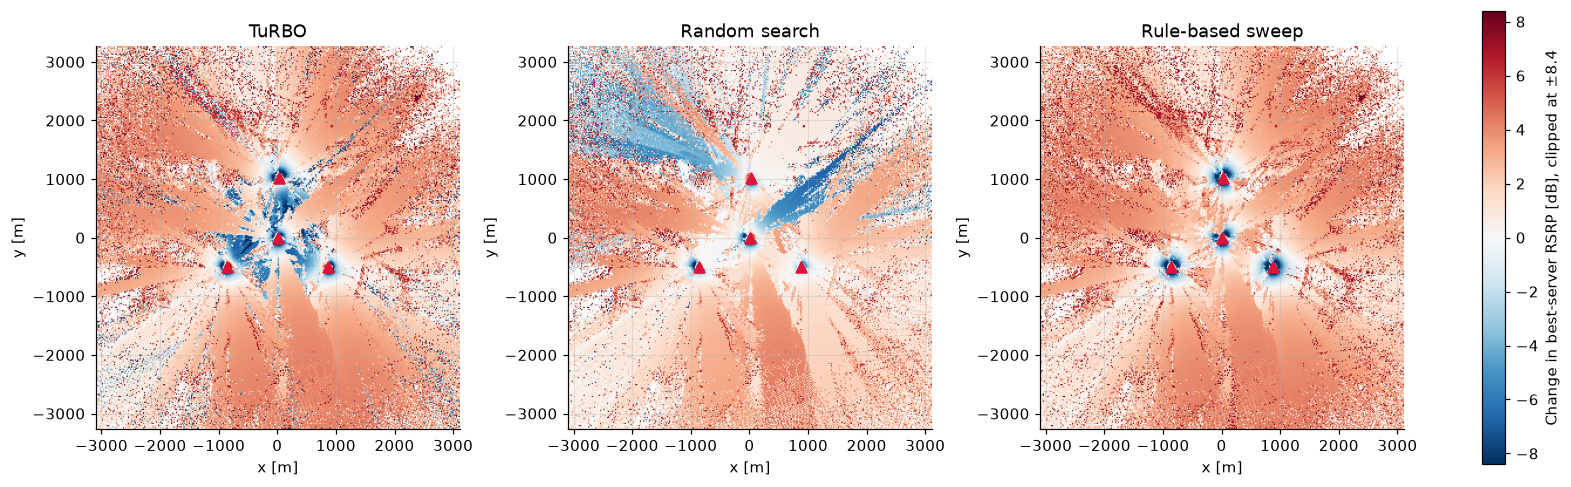

In [9]:
best_rsrp = {"incumbent": max_rsrp(baseline["rsrp_dbm"].astype(float))}
best_rsrp.update({m: max_rsrp(best[m].radio_map["rsrp_dbm"].astype(float)) for m in METHODS})

figure = plots.coverage_maps(
    best_rsrp["incumbent"], best_rsrp["turbo"], baseline, cfg, cells=cells, name="turbo"
)
save_fig(figure, "coverage_before_after_turbo")
plt.show()

# No path in either map makes the change undefined; it stays blank.
with np.errstate(invalid="ignore"):
    change = {label(m): best_rsrp[m] - best_rsrp["incumbent"] for m in METHODS}
figure = plots.map_row(
    change, baseline, colorbar_label="Change in best-server RSRP [dB]", symmetric=True, cells=cells
)
save_fig(figure, "rsrp_change_maps")
plt.show()

**Observations.** TuRBO raises best-server RSRP on 91.4 % of tiles, by a median of 2.5 dB, and closes 606 hole
tiles while opening 75. The rule sweep is the gentler change - 97.7 % of tiles improve, median +2.8 dB, 761 holes
closed and 1 opened - because it uptilts every cell on a band together and so lifts the whole scene rather than
trading one area against another. TuRBO's map is the mixed one: it accepts opened holes where the objective's demand
weights say little traffic stands, and buys separation elsewhere. Random search is the weakest of the three on this
view: 80.6 % of tiles improve, median +1.5 dB, and it opens 103 holes.

## 9. KPI-Level Analysis

Coverage classes by area and by demand, overlap, and which band serves the UEs, for the current configuration and
each method's best. Demand is the incumbent's for every configuration, so the weights do not move. Mean overlapping
neighbours is the diagnostic defined in 03a section 6; no score reads it.

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,TuRBO: Share of area,TuRBO: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand
0,hole,0.1125,0.000,0.1078,0.0049,0.1083,0.0027,0.1043,0.00
1,weak,0.3069,0.836,0.2650,0.7862,0.2864,0.7967,0.2539,0.77
2,good,0.5806,0.164,0.6273,0.2089,0.6054,0.2006,0.6418,0.23


,Configuration,Co-band overlap rate,Mean overlapping neighbours
0,Current configuration,0.3164,0.9625
1,TuRBO,0.3088,1.0343
2,Random search,0.3254,1.0303
3,Rule-based sweep,0.3212,1.1888


Band preference, most preferred first: 2600 MHz, 1800 MHz, 700 MHz


,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10087.0,0.4735,-0.3751,5.1257,53.1831,0.3408,0.1050,0.0807
1,TuRBO,10087.0,0.4053,0.3328,7.9721,38.8255,0.4582,0.0635,0.0730
2,Random search,10087.0,0.4118,0.2418,7.7253,39.8052,0.4506,0.0715,0.0661
3,Rule-based sweep,10087.0,0.4019,0.3822,7.7648,39.6459,0.4601,0.0659,0.0721


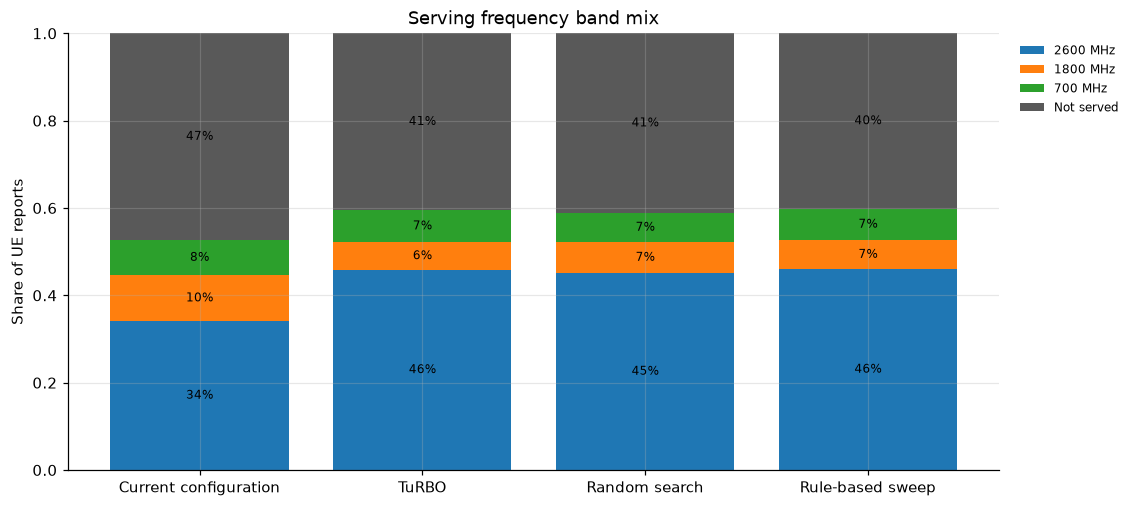

,Configuration,Band,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Peak PRB utilisation,Cell load imbalance (CoV)
0,Current configuration,All bands,0.1125,0.3164,0.9625,0.3069,-108.5644,-84.1068,-5.8729,8.4932,0.5265,0.7999,0.9098
1,Current configuration,2600 MHz,0.2884,0.2010,0.3703,0.5124,-115.4094,-98.0890,-17.5911,-1.6299,0.3408,0.7999,0.6775
2,Current configuration,1800 MHz,0.2350,0.2067,0.3564,0.4171,-112.4538,-91.7208,-11.6703,4.1494,0.1050,0.7994,0.6074
3,Current configuration,700 MHz,0.1381,0.2396,0.3691,0.2945,-108.5333,-83.9182,-5.2264,8.3972,0.0807,0.7991,0.9986
4,TuRBO,All bands,0.1078,0.3088,1.0343,0.2650,-107.3805,-81.5408,-5.0017,11.1267,0.5947,0.7993,1.0042
5,TuRBO,2600 MHz,0.2535,0.1915,0.4001,0.3885,-113.4256,-90.7770,-15.6261,3.3671,0.4582,0.7993,0.5730
6,TuRBO,1800 MHz,0.2195,0.2034,0.3845,0.3337,-111.2849,-87.2714,-10.5403,6.4169,0.0635,0.7970,0.8376
7,TuRBO,700 MHz,0.1373,0.2176,0.3756,0.2625,-107.5241,-81.9712,-4.6577,10.5065,0.0730,0.7960,1.1227
8,Random search,All bands,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092
9,Random search,2600 MHz,0.2587,0.1908,0.3972,0.4077,-113.9217,-91.9628,-16.1259,2.5799,0.4506,0.7998,0.5835


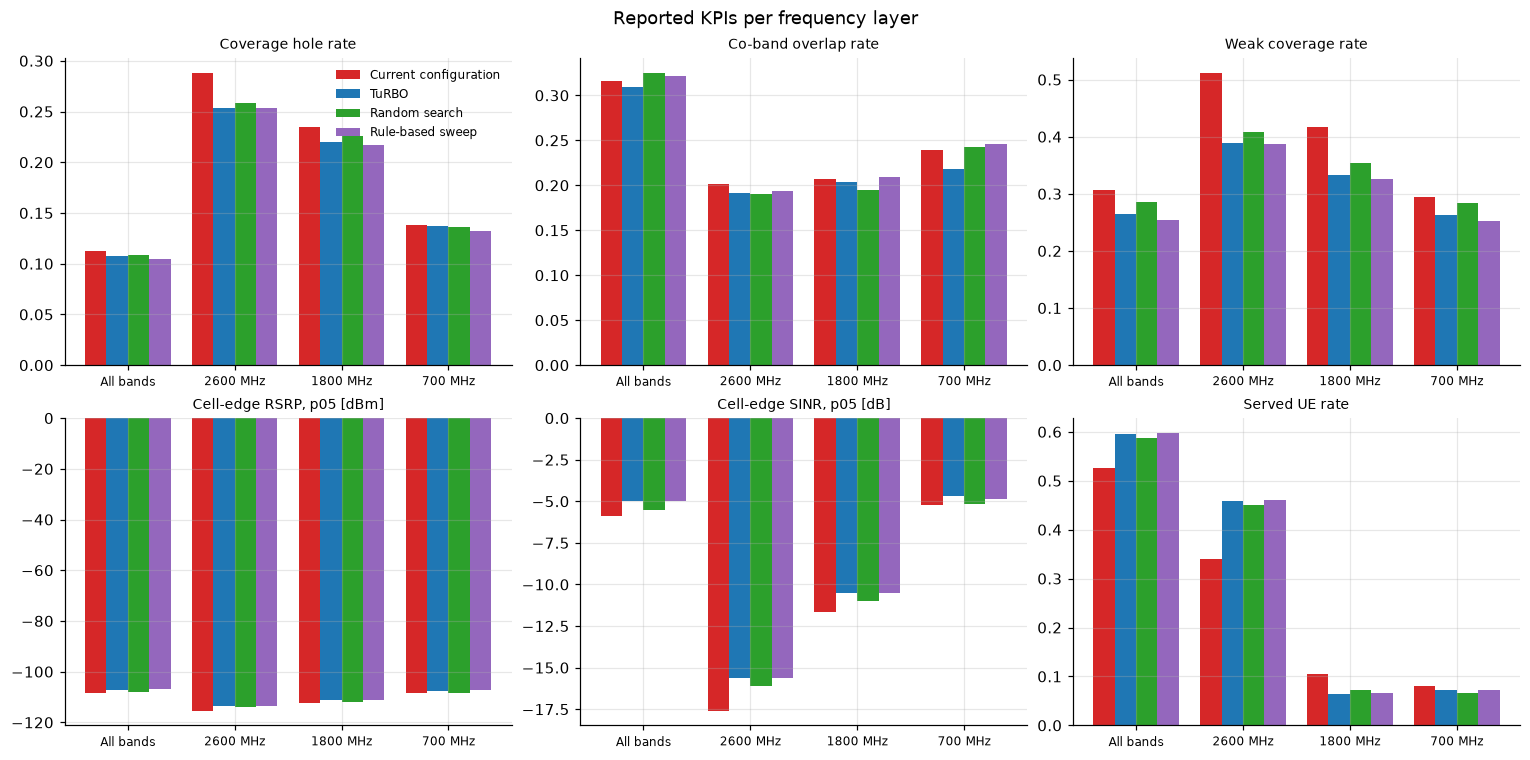

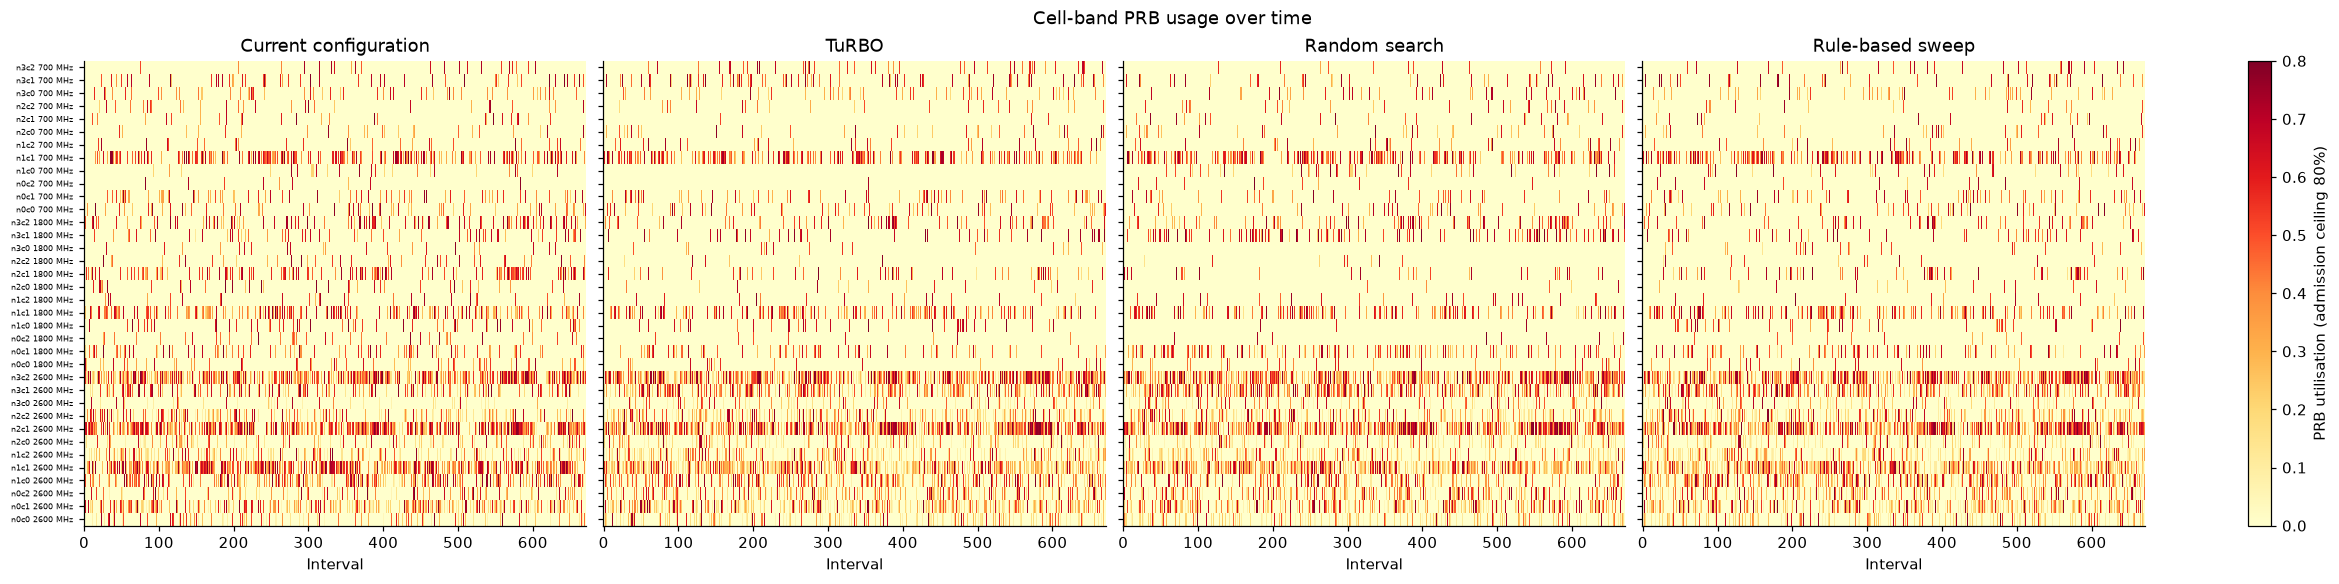

peak utilisation over every cell-band and interval: 80.0% (admission ceiling 80%)


In [10]:
def mean_overlap_neighbors(rsrp):
    covered = max_rsrp(rsrp) > float(cfg.kpi.hole_dbm)
    return float(overlap_neighbors(rsrp, cfg)[covered].mean())


configurations = {"incumbent": compare.configuration(baseline, ue, cfg)}
configurations.update({m: compare.configuration(best[m].radio_map, ue, cfg) for m in METHODS})
demand = configurations["incumbent"].demand

coverage = compare.coverage_comparison(
    {name: maps.coverage_table(c.rsrp, demand, cfg) for name, c in configurations.items()}
)
coverage.columns = ["coverage"] + [
    f"{label(key)}: {label(f'{share}_share')}"
    for key, share in (column.rsplit("_", 1) for column in coverage.columns[1:])
]
coverage = readable(coverage)
save_table(coverage, "coverage_by_area_and_demand")
display(coverage)

overlap = pd.DataFrame(
    {
        "configuration": list(configurations),
        "overlap_rate": [turbo.incumbent_kpi.overlap_rate]
        + [best[m].best_kpi.overlap_rate for m in METHODS],
        "Mean overlapping neighbours": [
            mean_overlap_neighbors(c.rsrp) for c in configurations.values()
        ],
    }
)
overlap = readable(overlap)
save_table(overlap, "overlap")
display(overlap)

band_labels = [str(band) for band in baseline["band_label"]]
print(
    "Band preference, most preferred first:",
    ", ".join(label(b) for b in cfg.kpi.capacity.band_preference),
)
service = {
    name: compare.service_summary(c.served, band_labels) for name, c in configurations.items()
}
service_table = readable(pd.DataFrame(service).T.rename_axis("configuration").reset_index())
save_table(service_table, "ue_service_summary")
display(service_table)
figure = plots.band_share_bars(service, band_labels)
save_fig(figure, "serving_band_mix")
plt.show()

tx_names = [str(name) for name in baseline["tx_name"]]
max_prb = CapacitySpec.from_config(cfg, band_labels, len(tx_names)).max_prb

# Every reported KPI, over all bands and per band, through the same functions:
# a band row is the definition given one band's layers, nothing new.
per_band = compare.band_kpis(configurations, band_labels, cfg)
save_table(readable(per_band), "band_kpis")
display(readable(per_band))
figure = plots.band_kpi_panels(
    per_band,
    ("hole_rate", "overlap_rate", "weak_rate", "rsrp_p05_dbm", "sinr_p05_db", "served_rate"),
)
save_fig(figure, "band_kpis")
plt.show()

# The series prb_utilisation_max and load_imbalance reduce. The admission
# ceiling bounds every cell in it, so a band running at the ceiling is a cell
# that refused traffic, not one that overloaded.
ceiling = float(cfg.kpi.capacity.max_admission_utilisation)
usage = compare.prb_usage_by_time(configurations, band_labels, tx_names, max_prb)
save_table(readable(usage), "prb_usage_by_time")
figure = plots.prb_usage_heatmaps(usage, ceiling)
save_fig(figure, "prb_usage")
plt.show()
print(f"peak utilisation over every cell-band and interval: {usage['utilisation'].max():.1%} "
      f"(admission ceiling {ceiling:.0%})")


### Coverage holes

The current configuration puts no demand at all on hole tiles. All three methods cut the hole rate by area (0.1125 to
0.1056 for TuRBO, 0.1042 for the sweep, 0.1083 for random search), and only random search moves any demand onto holes
in exchange (0.27 %); TuRBO and the sweep move none. That trade is what the demand weights
permit: a hole where the MDT saw nobody costs a capacity band nothing, and b2600 is at `alpha = 1`.

### Coverage overlap

TuRBO is the only method that lowers the overlap rate at all - 0.3164 to 0.3122 - against 0.3204 for the sweep and
0.3254 for random search. It also leaves the largest share of covered tiles with no neighbour (65.1 % against the
incumbent's 64.4 %). All three raise the mean neighbour count over covered tiles, because all three close holes and a
newly covered tile can acquire neighbours; under the softplus utility they raise it by more than any method did under
the logistic one. The sweep raises it most (0.963 to 1.206), then TuRBO (1.119), then random search (1.030).

### Multi-band coordination

The share of UE reports served on 2600 MHz grows from 34.1 % to 46.1 % under TuRBO, close to both baselines
(45.1 % and 46.1 %), while 1800 MHz falls from 10.5 % to 6.5 % and 700 MHz from 8.1 % to 7.1 %. The high band takes
the traffic and the mid band gives it up. Served SINR rises at both the median (5.1 to 7.8 dB) and the 10th
percentile (-0.4 to +0.4 dB), and the median PRBs per served UE falls from 53.2 to 39.5 - the same UEs served on a
stronger layer need fewer resources.

### Weak coverage

Weak coverage falls by area for every method (30.7 % to 25.7 % under TuRBO), and the share of demand on weak tiles
falls with it (83.6 % to 77.9 %). It is still where most of the demand sits.

### Per band

Section 9's per-band rows are where the per-band objective shows: every method cuts the hole rate on all three
layers, and the largest cut is on 2600 MHz - 0.288 to 0.252 under TuRBO, 12.5 % relative. Under the band-collapsed
objective those holes were invisible whenever 700 MHz covered the same tile.

### A note on scoring

Sections 5 to 8 are read back from `run.json`; this section re-measures the same radio maps from disk. Both now use
the same serving rule and the same objective, so the two agree — `run_store.verify` refuses to load runs that do not.
What this section adds is the per-band and per-tile detail `run.json` does not store, not a second accounting.

## 10. Key Observations

- TuRBO finds a mixed configuration, not a uniform uptilt: 34 of the 36 cell-bands uptilted and 2 downtilted, the
  largest move 11.9°, and no cell-band pinned to either end of its tilt box. Every proposed tilt now lands between
  0.1° and 8.6°, well below the 12/10/8° incumbent: under a coverage utility that keeps paying above $T_	ext{cov}$,
  uptilting to spread energy further is rewarded where it previously saturated.
- At the same budget and seed it beats random search on the objective (5.6972 against 5.5118), so the model-guided
  search adds value over sampling the box. Random search's best is evaluation 7 - a point in the Sobol design the two
  share - and it never improved on it in the remaining 137 evaluations.
- It beats the three-variable rule-based sweep on $J$ (5.6972 against 5.6756), but only passes it at evaluation 81 -
  three times the sweep's total budget - and its margin comes from co-band overlap, the one measure the sweep worsens
  most and TuRBO improves.
- The search was still improving late in its budget (best at evaluation 115 of 145, no restart), so the result is
  limited by the budget rather than by the trust region collapsing.
- It is also the method that unbalances cell load most (+11.0 %), which the objective does not read.
- The per-band objective shows up in the per-band KPIs of section 9: every method cuts the hole rate on all three
  layers, and the largest cut is on 2600 MHz (0.288 to 0.252 for TuRBO), the layer the band-collapsed objective could
  not see holes in at all.
- These are one seed on one scenario; notebook 04 reports intervals over seeds.

## 11. Limitations

- **Budget.** The best point is evaluation 115 of 144 and the region never collapsed, so a larger budget may still
  improve the result; this run does not show where TuRBO levels off.
- **Cost.** Every candidate is a full ray trace, and each round adds a GP fit, which grows with the evaluations since
  the last restart; wall clock is 14.2 minutes against random search's 11.2 at equal evaluations.
- **One trust region.** TuRBO searches around one incumbent; restarts are its only way to leave that basin, and none
  happened here.
- **The objective reads coverage and overlap only.** It is per band and demand-weighted now (ADR 0007), so a hole
  on one layer is visible and empty ground counts only as much as that band's `alpha` says - but it still does not
  read cell load.
- **The demand share comes from the MDT**, which holds served reports only, so ground the network already fails to
  cover is under-represented in the map that decides where coverage matters. Counting reports rather than their PRBs
  removes the SINR half of that bias, not the MDT half.
- **A band at `alpha = 1` is scored on the reported tiles alone**, about 3 % of the grid, with no kernel to fill the
  rest. That term is a high-variance estimate and its optimum moves with the UE sampling seed (ADR 0007,
  Consequences).
- **Winner's curse.** The winner is the best of many evaluations under one solver seed, so its score is biased
  upward (notebook 04, threats to validity).
- **No movement constraint.** Tilt change is reported, not penalised, so the proposal moves all 36 antennas, one by
  11.9°.

## 12. Conclusion

TuRBO is a working, reproducible model-guided search for multi-band tilt on this scenario. It:

- beats random search at the same budget and seed, starting from the same Sobol design;
- beats the rule-based sweep's objective with per-cell-band tilts, and with the lowest co-band overlap and the highest
  median SINR of the three methods;
- improves 10 of the 12 reported measures, worsening only overlap neighbours per covered tile and cell load imbalance;
- was still improving late in its budget.

The margin over the sweep is narrower than before - 5.6972 against 5.6756, on a scale where the incumbent sits at
5.0568, so the sweep now captures about 97 % of TuRBO's gain for a fifth of the evaluations. Under the logistic
utility it captured 89 %. The softplus change rewards broad signal strength, which a three-variable per-band sweep
can deliver almost as well as a 36-variable search, so it narrows TuRBO's advantage rather than widening it. Whether
that margin holds, and justifies about five times the evaluations, is decided over seeds in notebook 04.